# Classifier-Free Guidance (CFG) with Flow Matching

Ho & Salimans, 2022 — https://arxiv.org/abs/2207.12598

## The idea in one line

We want to sample from $p(x \mid y)$ (data conditioned on a label).  By Bayes' rule:

$$\log p(x \mid y) \;=\; \log p(y \mid x) + \log p(x) - \log p(y).$$

Taking gradients in $x$ (the constant $\log p(y)$ drops out) we get the *score* identity

$$\nabla_x \log p(x \mid y) \;=\; \underbrace{\nabla_x \log p(y \mid x)}_{\text{classifier gradient}} + \nabla_x \log p(x).$$

### Step 1 — sharpen the posterior (a *definition*, not a derivation)

In practice $p(y \mid x)$ is often too "soft" (the model is uncertain), so a sampler that follows $\nabla_x \log p(x\mid y)$ wanders off the conditioned mode. We *choose* to instead sample from a sharper distribution that puts more mass where the classifier is confident.

There is no unique "correct" way to sharpen, but a very natural one is **tempering the classifier** — raising $p(y\mid x)$ to a power $\gamma = 1 + w > 0$. Two equivalent ways to write that choice:

Start from plain Bayes, $p(x \mid y) \propto p(x)\,p(y\mid x)$, and replace the classifier by a tempered version:

$$\tilde p_w(x \mid y) \;\propto\; p(x)\,\cdot\,p(y \mid x)^{1+w}.$$

Pull one factor of $p(y\mid x)$ back into $p(x)$ using Bayes ($p(x)\,p(y\mid x) \propto p(x\mid y)$, treating $y$ as fixed so $p(y)$ is a constant in $x$):

$$\tilde p_w(x \mid y) \;\propto\; p(x \mid y)\,\cdot\,p(y \mid x)^{w}.$$

Both forms describe the **same** distribution; the second one is just more convenient for what comes next.

Sanity checks on this choice:
- $w = 0$ ⇒ $\tilde p_0 = p(x\mid y)$ — we recover the true posterior.
- $w \to \infty$ ⇒ all mass concentrates where the classifier is maximally confident — pure mode-seeking.
- $w = -1$ ⇒ $\tilde p_{-1} \propto p(x)$ — the label cancels out, unconditional sampling.

This is exactly the temperature trick: $p(y\mid x)^{1+w}$ is a Boltzmann distribution at inverse temperature $1+w$. Higher $w$ = lower temperature = sharper.

Why *this* form and not, say, $p(x\mid y)^{1+w}$? Because we only want to sharpen *the label-dependent part*, not the data prior — sharpening $p(x\mid y)$ itself would also concentrate samples onto the modes of the data even in places where the label doesn't care. Tempering the classifier $p(y\mid x)$ leaves the data prior intact.

Taking $\nabla_x \log$ of both sides (the proportionality constant has no $x$ dependence):

$$\nabla_x \log \tilde p_w(x \mid y) \;=\; \nabla_x \log p(x \mid y) \;+\; w\,\nabla_x \log p(y \mid x).$$

### Step 2 — kill the classifier

Now substitute the Bayes identity $\nabla_x \log p(y \mid x) = \nabla_x \log p(x \mid y) - \nabla_x \log p(x)$:

$$\nabla_x \log \tilde p_w(x \mid y) \;=\; \nabla_x \log p(x \mid y) \;+\; w\bigl(\nabla_x \log p(x \mid y) - \nabla_x \log p(x)\bigr)$$

$$\;=\; (1+w)\,\nabla_x \log p(x \mid y) \;-\; w\,\nabla_x \log p(x).$$

So a single conditional + unconditional network is enough — no classifier required. The same linear combination works for the **velocity field** in flow matching (because velocity is an affine function of the score):

$$v_w(z, t, y) \;=\; (1+w)\,v_\theta(z, t, y) \;-\; w\,v_\theta(z, t, \varnothing).$$

## Training recipe

Train a single conditional model $v_\theta(z, t, y)$ where the label $y$ is randomly replaced by a null token $\varnothing$ with probability $p_{\text{uncond}}$ (typically 10–20%). That one network gives us both the conditional and unconditional velocities at inference time.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from sklearn.datasets import make_blobs
import seaborn as sns

from common import Residual, SinusoidalTimeEmbedding, load_or_train

%matplotlib inline
torch.manual_seed(0)
np.random.seed(0)


## Dataset: labeled blobs

`sklearn.datasets.make_blobs` gives well-separated Gaussian clusters and a label per point — exactly what we need to make CFG visible. We standardize so the data has unit scale (matching the noise prior).

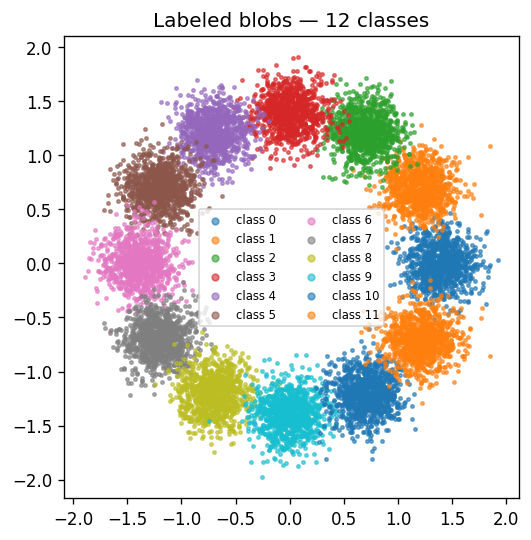

In [ ]:
N_CLASSES = 6
centers = np.array([
    [ 2.5,  0.0],
    [ 1.25,  2.2],
    [-1.25,  2.2],
    [-2.5,  0.0],
    [-1.25, -2.2],
    [ 1.25, -2.2],
])
X, y = make_blobs(n_samples=12000, centers=centers, cluster_std=0.30, random_state=0)
X = (X - X.mean(0)) / X.std(0)

train_x = torch.tensor(X, dtype=torch.float32)
train_y = torch.tensor(y, dtype=torch.long)

palette = plt.get_cmap('tab10')
fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
for k in range(N_CLASSES):
    m = (y == k)
    ax.scatter(X[m, 0], X[m, 1], s=4, label=f'class {k}', alpha=0.6)
ax.set_aspect('equal')
ax.legend(markerscale=2, loc='center', fontsize=8)
ax.set_title('Labeled blobs — 6 classes')
plt.show()


## A label-conditioned velocity network

We extend the tiny MLP from `common.py` with a label embedding. The null label $\varnothing$ is just one extra embedding slot (index `N_CLASSES`).

In [4]:
class CondMLP(nn.Module):
    """Time- and label-conditioned MLP. Label index == N_CLASSES is the null token."""
    def __init__(self, num_in, hidden, n_classes, time_dim=32, cond_dim=32, n_residual=4):
        super().__init__()
        self.n_classes = n_classes
        self.null_idx = n_classes  # last slot reserved for unconditional
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        self.label_embed = nn.Embedding(n_classes + 1, cond_dim)

        in_features = num_in + time_dim + cond_dim
        layers = [nn.Linear(in_features, hidden), nn.GELU()]
        layers += [Residual(hidden) for _ in range(n_residual)]
        layers += [nn.GELU(), nn.Linear(hidden, num_in)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, z, t, y):
        t_feat = self.time_embed(t)
        y_feat = self.label_embed(y)
        return self.mlp(torch.cat([z, t_feat, y_feat], dim=1))

## Training: flow matching with random label dropout

Same flow-matching velocity target $v = e - x$ (with $z_t = (1-t)x + t e$).  The only new piece is replacing the label with the null index with probability `P_UNCOND`. That single network ends up parameterising both $v_\theta(z, t, y)$ and $v_\theta(z, t, \varnothing)$.

Loaded cfg_blobs from checkpoints/cfg_blobs.pt


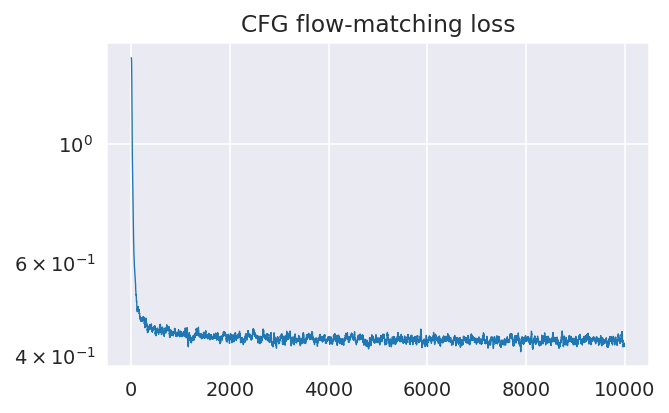

In [ ]:
P_UNCOND = 0.15  # drop the label with this probability during training

def make_train_step(train_y_all, p_uncond, null_idx):
    def train_step(x, net, optimizer):
        idx = torch.randint(0, len(train_y_all), (len(x),), device=x.device)
        x_b = train_x_dev[idx]
        y_b = train_y_all[idx].clone()

        drop = torch.rand(len(y_b), device=y_b.device) < p_uncond
        y_b[drop] = null_idx

        t = torch.rand(len(x_b), 1, device=x_b.device)
        e = torch.randn_like(x_b)
        z = (1 - t) * x_b + t * e
        v_target = e - x_b

        v_pred = net(z, t, y_b)
        loss = F.mse_loss(v_pred, v_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        return loss
    return train_step

device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_x_dev = train_x.to(device)
train_y_dev = train_y.to(device)

model = CondMLP(num_in=2, hidden=64, n_classes=N_CLASSES, time_dim=32, cond_dim=32)
train_step = make_train_step(train_y_dev, P_UNCOND, model.null_idx)

losses = load_or_train(
    model, name="cfg_blobs", train_step=train_step,
    data=train_x, niter=10000, lr=1e-3,
    ckpt_dir="checkpoints", batch_size=1024,
    load=True, save=True,
)

with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(5, 3), dpi=140)
    ax.semilogy(losses, lw=0.7)
    ax.set_title('CFG flow-matching loss')
    plt.show()


## Inference with classifier-free guidance

At each Euler step we evaluate the network **twice** — once with the true label, once with the null token — and combine:

$$v_w(z, t, y) = (1+w)\,v_\theta(z, t, y) - w\,v_\theta(z, t, \varnothing).$$

- $w = 0$: pure conditional model.
- $w > 0$: push samples *toward* the conditional mode (sharper, less diverse).
- $w = -1$: pure unconditional sampler (label ignored).

Trick to halve the cost: stack the conditional and unconditional inputs into one forward pass.

In [6]:
@torch.no_grad()
def sample_cfg(model, labels, w=0.0, n_steps=100):
    """Euler integration of the CFG-combined velocity field, t: 1 -> 0."""
    model.eval()
    device = next(model.parameters()).device
    labels = labels.to(device)
    n = labels.shape[0]
    null = torch.full_like(labels, model.null_idx)

    z = torch.randn(n, 2, device=device)
    dt = 1.0 / n_steps
    for i in range(n_steps):
        t = torch.full((n, 1), 1.0 - i * dt, device=device)
        # one batched forward pass for cond + uncond
        z2 = torch.cat([z, z], 0)
        t2 = torch.cat([t, t], 0)
        y2 = torch.cat([labels, null], 0)
        v_all = model(z2, t2, y2)
        v_cond, v_uncond = v_all.chunk(2, dim=0)
        v = (1 + w) * v_cond - w * v_uncond
        z = z - v * dt
    return z.cpu()

### Sweep the guidance scale

We sample 500 points per class for several values of $w$ and compare side by side.

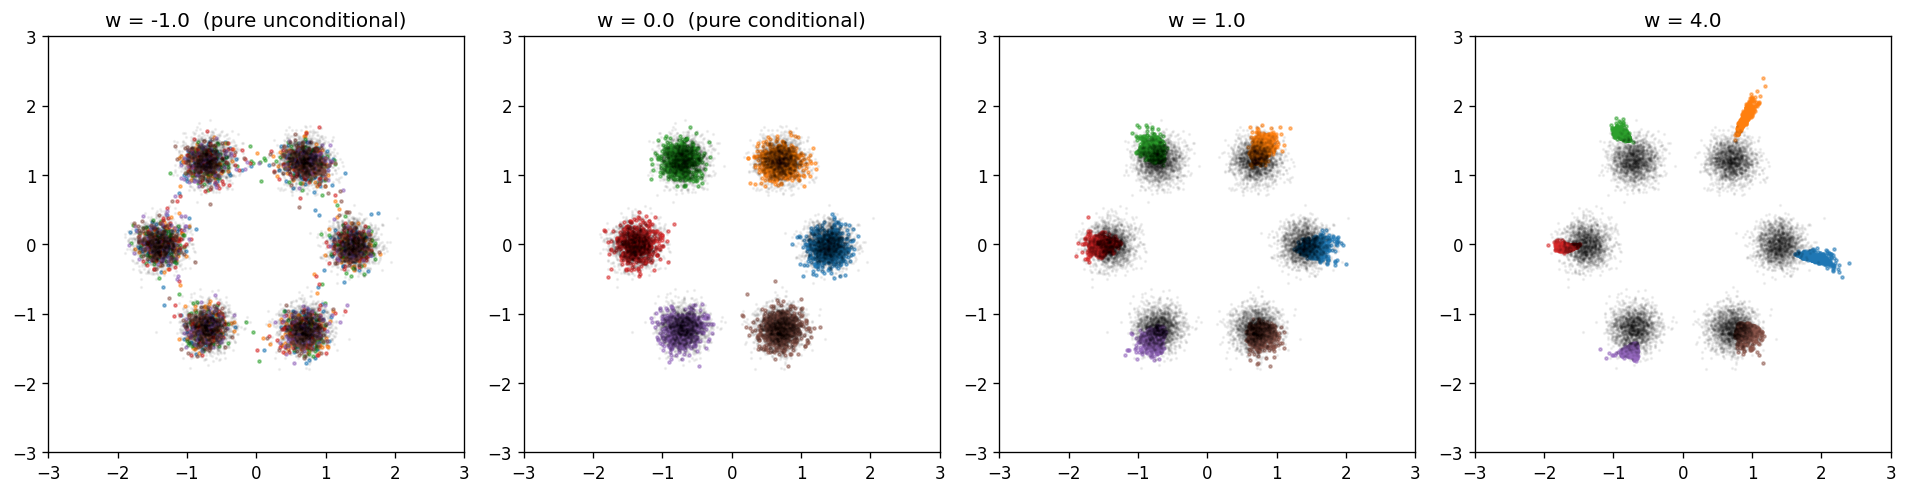

In [7]:
n_per_class = 500
labels = torch.arange(N_CLASSES).repeat_interleave(n_per_class)
ws = [-1.0, 0.0, 1.0, 4.0]

fig, axes = plt.subplots(1, len(ws), figsize=(4 * len(ws), 4), dpi=120)
palette = plt.get_cmap('tab10')
for ax, w in zip(axes, ws):
    samples = sample_cfg(model, labels, w=w, n_steps=100).numpy()
    for k in range(N_CLASSES):
        m = (labels.numpy() == k)
        ax.scatter(samples[m, 0], samples[m, 1], s=3, alpha=0.5, color=palette(k))
    # overlay true data as gray reference
    ax.scatter(X[:, 0], X[:, 1], s=1, color='black', alpha=0.05)
    title = f'w = {w}'
    if w == -1.0:
        title += '  (pure unconditional)'
    elif w == 0.0:
        title += '  (pure conditional)'
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.tight_layout()
plt.show()

### What to look for

- **$w = -1$**: clusters are ignored — points spread across the whole distribution, colored arbitrarily.
- **$w = 0$**: conditional samples roughly match the true cluster widths.
- **$w > 0$**: samples concentrate near each cluster center; spread shrinks.
- **Large $w$**: clusters collapse and you can see *mode contraction* — characteristic of CFG.

### A single forward pass with stacking

Note in `sample_cfg` we stacked the conditional and unconditional inputs into one batched call. This is the standard trick in image-CFG implementations: ~1 extra forward per step instead of 2.

## Visualizing the guided velocity field

We can also evaluate $v_w(z, t=0.5, y)$ on a grid for a fixed class to see how guidance reshapes the flow toward that cluster.

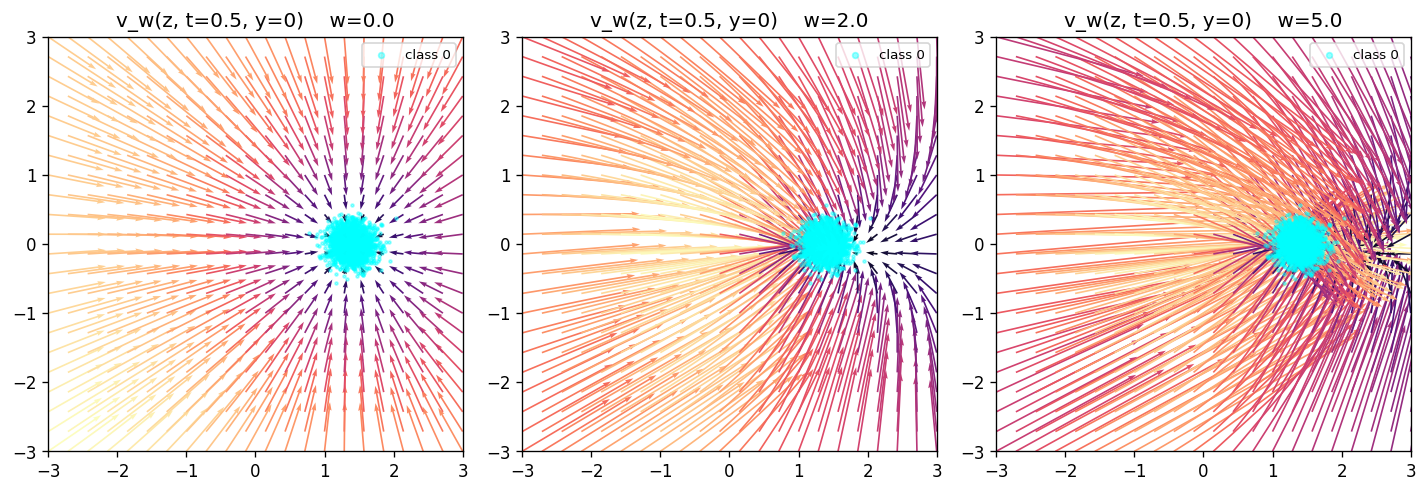

In [8]:
@torch.no_grad()
def velocity_field(model, target_class, w, t_val=0.5, grid=24, lim=3.0):
    model.eval()
    device = next(model.parameters()).device
    xs = torch.linspace(-lim, lim, grid)
    ys = torch.linspace(-lim, lim, grid)
    gx, gy = torch.meshgrid(xs, ys, indexing='xy')
    z = torch.stack([gx.flatten(), gy.flatten()], dim=1).to(device)
    t = torch.full((z.shape[0], 1), t_val, device=device)
    y = torch.full((z.shape[0],), target_class, dtype=torch.long, device=device)
    null = torch.full_like(y, model.null_idx)
    v_cond = model(z, t, y)
    v_uncond = model(z, t, null)
    v = (1 + w) * v_cond - w * v_uncond
    # invert so arrows point in the data-generation direction (t decreases)
    return gx.numpy(), gy.numpy(), (-v[:, 0]).cpu().numpy(), (-v[:, 1]).cpu().numpy()

target_class = 0
ws_vis = [0.0, 2.0, 5.0]
fig, axes = plt.subplots(1, len(ws_vis), figsize=(4 * len(ws_vis), 4), dpi=120)
for ax, w in zip(axes, ws_vis):
    gx, gy, u, v = velocity_field(model, target_class, w=w, t_val=0.5, grid=22)
    speed = np.sqrt(u**2 + v**2).reshape(gx.shape)
    ax.quiver(gx, gy, u.reshape(gx.shape), v.reshape(gx.shape), speed,
              cmap='magma', scale=40, width=0.004)
    # show true cluster center
    m = (y == target_class)
    ax.scatter(X[m, 0], X[m, 1], s=3, color='cyan', alpha=0.4, label=f'class {target_class}')
    ax.set_title(f'v_w(z, t=0.5, y={target_class})    w={w}')
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.legend(loc='upper right', fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

Notice how, as $w$ grows, the arrows everywhere bend more sharply toward the chosen cluster — that's literally $\nabla_x \log p(y \mid x)$ being added on top of the unconditional score.

## Semi-supervised learning via CFG

**Setup**: we reveal labels for only **30 %** of the training pool. The remaining 70 % stay as unlabeled data points — the model can see them but not their class.

**CFG training rule**: the null token $\varnothing$ replaces the label whenever:
- the label was dropped from the dataset (70 % of points), **or**
- random CFG dropout fires (the usual $p_{\text{uncond}}$ ≈ 15 %).

Formally: `use_label = has_label AND (not random_drop)` — i.e. the "AND" of the two conditions for keeping a label.

After training, we compare three classifiers:
- **(A) Full supervision** — trained on 100 % labeled pool (upper bound).
- **(B) Direct 30 %** — trained only on the 3 k labeled points, no generative model.
- **(C) CFG-regenerated** — generates fresh $(x, y)$ pairs from the semi-supervised model; classifier trains on those.

Pool: 10,000  |  labeled: 1,026 (10%)  |  unlabeled: 8,974  |  test: 2,000


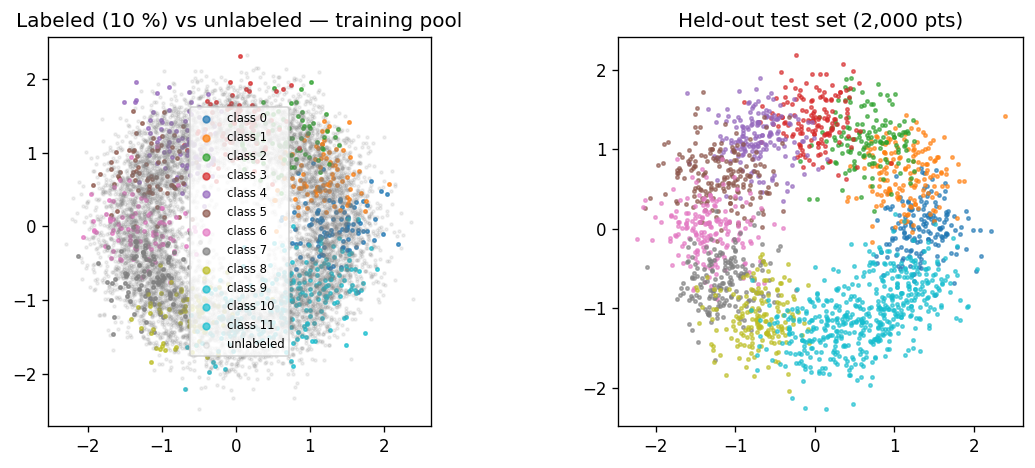

In [ ]:
# ── Dataset: test split + 30 % label dropout ─────────────────────────────────
LABEL_KEEP_FRAC = 0.30

torch.manual_seed(99)
perm   = torch.randperm(len(train_x))
n_test = 2000

test_x = train_x[perm[:n_test]]
test_y = train_y[perm[:n_test]]
pool_x = train_x[perm[n_test:]]    # all data available to the model
pool_y = train_y[perm[n_test:]]    # ground-truth — NOT given to the model

torch.manual_seed(7)
label_mask = torch.rand(len(pool_x)) < LABEL_KEEP_FRAC
labeled_x  = pool_x[label_mask]
labeled_y  = pool_y[label_mask]

n_labeled   = label_mask.sum().item()
n_unlabeled = (~label_mask).sum().item()
print(f"Pool: {len(pool_x):,}  |  labeled: {n_labeled:,} ({100*n_labeled/len(pool_x):.0f}%)"
      f"  |  unlabeled: {n_unlabeled:,}  |  test: {n_test:,}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)
for k in range(N_CLASSES):
    m = labeled_y.numpy() == k
    axes[0].scatter(labeled_x[m, 0], labeled_x[m, 1],
                    s=4, alpha=0.7, color=palette(k), label=f'class {k}')
axes[0].scatter(pool_x[~label_mask, 0], pool_x[~label_mask, 1],
                s=3, alpha=0.12, color='gray', label='unlabeled')
axes[0].set_title(f'Labeled ({LABEL_KEEP_FRAC*100:.0f} %) vs unlabeled — training pool')
axes[0].set_aspect('equal')
axes[0].legend(markerscale=2, fontsize=7, loc='center')

for k in range(N_CLASSES):
    m = test_y.numpy() == k
    axes[1].scatter(test_x[m, 0], test_x[m, 1], s=4, alpha=0.6, color=palette(k))
axes[1].set_title(f'Held-out test set ({n_test:,} pts)')
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()


In [34]:
# ── Simple discriminative classifier ─────────────────────────────────────────
class SimpleClassifier(nn.Module):
    """Tiny 2-D → N_CLASSES classifier."""
    def __init__(self, n_classes, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.GELU(),
            Residual(hidden), Residual(hidden),
            nn.GELU(), nn.Linear(hidden, n_classes),
        )
    def forward(self, x): return self.net(x)

def train_clf(x_data, y_data, n_classes=N_CLASSES, niter=3000, lr=1e-3, bs=512):
    clf = SimpleClassifier(n_classes).to(device)
    xd, yd = x_data.to(device), y_data.to(device)
    opt = torch.optim.AdamW(clf.parameters(), lr=lr)
    for _ in range(niter):
        idx  = torch.randint(0, len(xd), (bs,), device=device)
        loss = F.cross_entropy(clf(xd[idx]), yd[idx])
        opt.zero_grad(); loss.backward(); opt.step()
    return clf

@torch.no_grad()
def test_acc(clf, x_data, y_data):
    clf.eval()
    preds = clf(x_data.to(device)).argmax(1).cpu()
    return (preds == y_data).float().mean().item()

# (A) Full supervision — upper bound
clf_full = train_clf(pool_x, pool_y)
acc_full = test_acc(clf_full, test_x, test_y)
print(f"(A) Full labels (100%)       → {acc_full*100:.1f}%")

# (B) Discriminative classifier trained directly on the 30 % labeled subset
print("num labeled: ", len(labeled_x), '/ ', len(pool_x))
clf_x  = train_clf(labeled_x, labeled_y)
acc_x  = test_acc(clf_x,  test_x, test_y)
print(f"(B) Direct — {LABEL_KEEP_FRAC*100:.0f}% labels only → {acc_x*100:.1f}%")

(A) Full labels (100%)       → 73.5%
num labeled:  1026 /  10000
(B) Direct — 10% labels only → 70.5%


loss = 1.358673: 100%|███████████████████████████████████████| 10000/10000 [01:05<00:00, 152.60it/s]


Saved cfg_blobs_semi_12cls to checkpoints/cfg_blobs_semi_12cls.pt


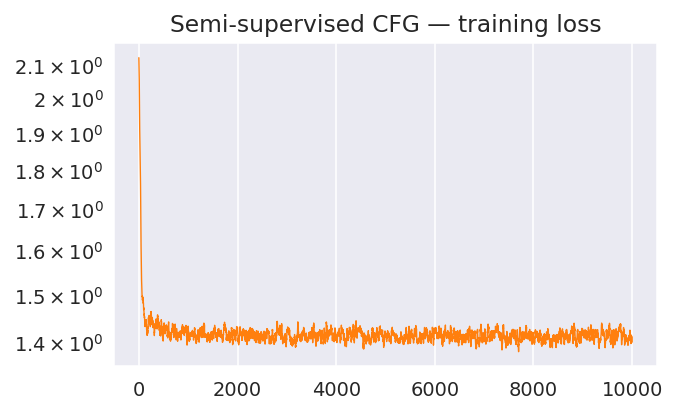

In [ ]:
# ── Semi-supervised CFG: null token = (label absent) OR (random CFG dropout) ─
pool_x_dev     = pool_x.to(device)
pool_y_dev     = pool_y.to(device)
label_mask_dev = label_mask.to(device)

def make_semi_train_step(p_uncond, null_idx):
    def train_step(x, net, optimizer):
        idx = torch.randint(0, len(pool_x_dev), (len(x),), device=x.device)
        x_b = pool_x_dev[idx]
        y_b = pool_y_dev[idx].clone()

        # Use label only when: label IS present  AND  not randomly dropped
        has_label   = label_mask_dev[idx]
        random_drop = torch.rand(len(y_b), device=y_b.device) < p_uncond
        y_b[~has_label | random_drop] = null_idx   # absent ∨ dropped → null

        t        = torch.rand(len(x_b), 1, device=x_b.device)
        e        = torch.randn_like(x_b)
        z        = (1 - t) * x_b + t * e
        v_target = e - x_b
        v_pred   = net(z, t, y_b)
        loss     = F.mse_loss(v_pred, v_target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        return loss
    return train_step

semi_model = CondMLP(num_in=2, hidden=64, n_classes=N_CLASSES, time_dim=32, cond_dim=32)
semi_step  = make_semi_train_step(P_UNCOND, semi_model.null_idx)

semi_losses = load_or_train(
    semi_model, name="cfg_blobs_semi", train_step=semi_step,
    data=pool_x, niter=10000, lr=1e-3,
    ckpt_dir="checkpoints", batch_size=1024,
    load=True, save=True,
)

with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(5, 3), dpi=140)
    ax.semilogy(semi_losses, lw=0.7, color='tab:orange')
    ax.set_title('Semi-supervised CFG — training loss')
    plt.show()


(C) CFG-regenerated (w=0.0) → 99.9%


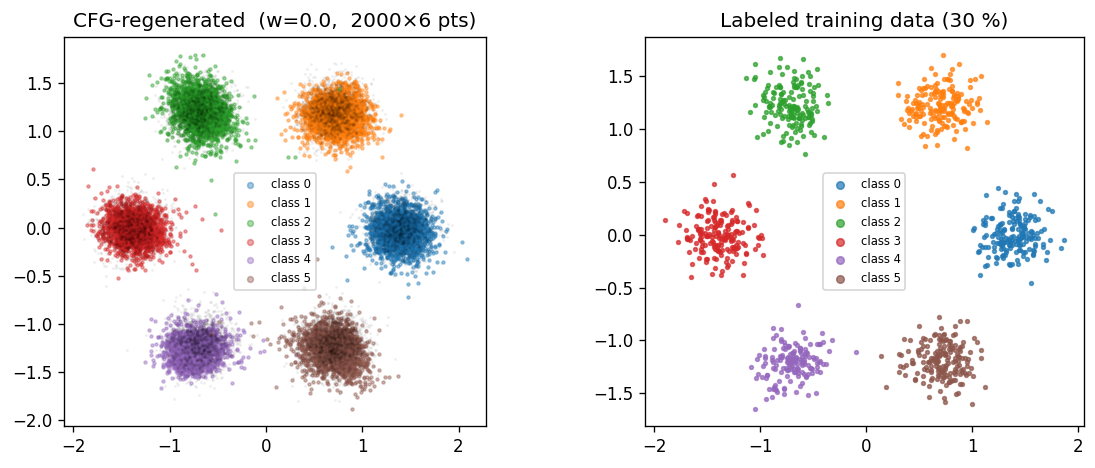


────────────────────────────────────────────────────
Method                              Accuracy
────────────────────────────────────────────────────
(A) Full labels (100%)               100.0%  ██████████████████████████████
(B) Direct — 10% labels              100.0%  ██████████████████████████████
(C) CFG-regen (semi-sup)              99.9%  █████████████████████████████
────────────────────────────────────────────────────


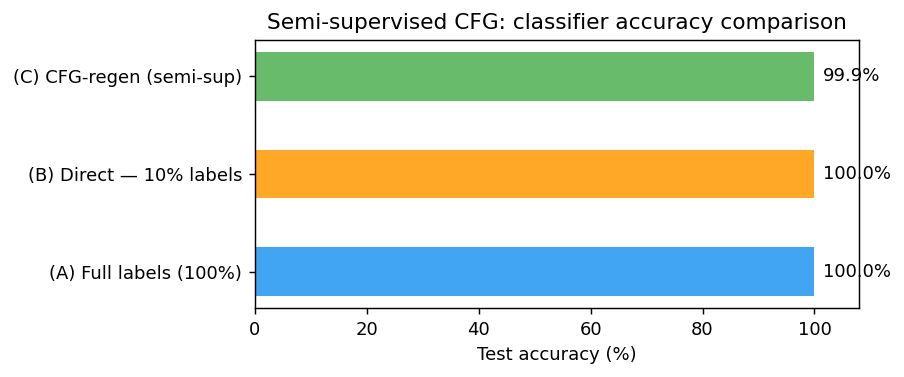

In [ ]:
# ── (C) Regenerate (x̂, y) pairs from the semi-supervised CFG model ────────────
N_GEN_PER_CLASS = 2000
W_GEN           = 0.0   # mild guidance — good balance of fidelity vs diversity

labels_gen = torch.arange(N_CLASSES).repeat_interleave(N_GEN_PER_CLASS)
gen_x      = sample_cfg(semi_model, labels_gen, w=W_GEN, n_steps=100)
gen_y      = labels_gen.clone()

clf_regen = train_clf(gen_x, gen_y)
acc_regen = test_acc(clf_regen, test_x, test_y)
print(f"(C) CFG-regenerated (w={W_GEN}) → {acc_regen*100:.1f}%")

# Visualise generated data vs labeled training data
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
for k in range(N_CLASSES):
    m = labels_gen.numpy() == k
    axes[0].scatter(gen_x[m, 0], gen_x[m, 1], s=3, alpha=0.4, color=palette(k), label=f'class {k}')
axes[0].scatter(pool_x[:, 0], pool_x[:, 1], s=1, color='black', alpha=0.04)
axes[0].set_title(f'CFG-regenerated  (w={W_GEN},  {N_GEN_PER_CLASS}×{N_CLASSES} pts)')
axes[0].set_aspect('equal')
axes[0].legend(markerscale=3, fontsize=8)

for k in range(N_CLASSES):
    m = labeled_y.numpy() == k
    axes[1].scatter(labeled_x[m, 0], labeled_x[m, 1], s=12, alpha=0.8, color=palette(k), label=f'class {k}')
axes[1].set_title(f'Labeled training data ({LABEL_KEEP_FRAC*100:.0f} %)')
axes[1].set_aspect('equal')
axes[1].legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

# ── Accuracy comparison ───────────────────────────────────────────────────────
results = {
    "(A) Full labels (100%)":             acc_full,
    f"(B) Direct — {LABEL_KEEP_FRAC*100:.0f}% labels": acc_x,
    "(C) CFG-regen (semi-sup)":           acc_regen,
}

print("\n" + "─" * 52)
print(f"{'Method':<34s}  {'Accuracy':>8s}")
print("─" * 52)
for name, acc in results.items():
    bar = "█" * int(acc * 30)
    print(f"{name:<34s}  {acc*100:6.1f}%  {bar}")
print("─" * 52)

fig, ax = plt.subplots(figsize=(7, 3), dpi=130)
names  = list(results.keys())
vals   = [v * 100 for v in results.values()]
colors = ['#2196F3', '#FF9800', '#4CAF50']
bars   = ax.barh(names, vals, color=colors, alpha=0.85, height=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=5)
ax.set_xlim(0, 108)
ax.set_xlabel('Test accuracy (%)')
ax.set_title('Semi-supervised CFG: classifier accuracy comparison')
plt.tight_layout()
plt.show()
